# Optional Practice Assignment: Regression Algorithms Deep Dive

**Note:** This is an OPTIONAL assignment to help you practice and reinforce the concepts from today's lecture. Take your time and work through the problems at your own pace!

**Questions?** Feel free to bring any questions to office hours or your study group. We're here to help!

## What We Covered in Class

Today we dove deeper into regression algorithms: Multiple Linear Regression, Polynomial Regression, Decision Trees, and touched on Lasso/Ridge regularization. Most importantly, we learned how to **detect overfitting** by comparing training vs test performance.

## Why This Matters for AI/ML

These problems are framed around real AI/ML scenarios to help you see how the programming concepts we're learning apply to building intelligent systems. You're not just learning to code - you're learning to build AI!

## Instructions

Complete each problem below by filling in the code where you see `# Your code here`.

Each problem includes:
- A description of what you need to do
- Starter code (imports, data loading, etc.)
- Test cases in a separate cell below (run this cell to verify your solution)

**How to work through problems:**
1. Read the problem description carefully
2. Write your solution in the code cell
3. Run your code cell
4. Run the test cell below it to verify your solution
5. When you see "All tests passed!", you're ready to move on!

## Setup: Import Libraries

Run this cell first to import all the libraries we'll need.

In [2]:
# Run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# For nicer plots
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


---

## Section 1: Data Loading & Exploration

**AI Context:** Before building any model, data scientists always explore their data first. Understanding your data is the foundation of successful machine learning!

We'll be using two datasets from Day 3:
- **car_prices.csv** - Mileage vs Price (good for polynomial regression)
- **simple_housing.csv** - SquareFootage, Bedrooms vs Price (good for multiple linear regression)

### Problem 1.1: Load the Car Prices Data

A car dealership wants to predict used car trade-in values. Load the car prices dataset and explore its structure.

**What you need to do:**
1. Load `car_prices.csv` into a DataFrame called `car_df`
2. Display the shape of the data
3. Display the first 5 rows

In [3]:
# Problem 1.1: Load the car prices data

# Your code here - load the CSV file
car_df = pd.read_csv("./car_prices.csv")# None  # Replace None with your code

# Display the shape
print(f"Car data shape: {car_df.shape}")

# Display first 5 rows
car_df.head()

Car data shape: (80, 2)


,Mileage,Price
0,5801,31184
1,7985,30712
2,9986,27292
3,11558,26810
4,11735,25328


In [4]:
# Test cases for Problem 1.1 - DO NOT MODIFY
assert car_df is not None, "car_df should not be None - did you load the data?"
assert isinstance(car_df, pd.DataFrame), "car_df should be a pandas DataFrame"
assert 'Mileage' in car_df.columns, "DataFrame should have 'Mileage' column"
assert 'Price' in car_df.columns, "DataFrame should have 'Price' column"
assert len(car_df) > 50, "DataFrame should have more than 50 rows"

print("✓ All tests passed!")

✓ All tests passed!


### Problem 1.2: Load the Housing Data

A real estate company wants to predict house prices using multiple features. Load the housing dataset and display basic statistics.

**What you need to do:**
1. Load `simple_housing.csv` into a DataFrame called `housing_df`
2. Display basic statistics using `.describe()`

In [5]:
# Problem 1.2: Load the housing data

# Your code here - load the CSV file
housing_df = pd.read_csv("./simple_housing.csv")

# Display basic statistics
housing_df.describe()

,SquareFootage,Bedrooms,Price
count,55.000000,55.000000,55.000000
mean,1871.909091,3.581818,287000.000000
std,356.113916,0.994260,61927.974891
min,1200.000000,2.000000,178000.000000
25%,1587.500000,3.000000,236500.000000
50%,1850.000000,4.000000,285000.000000
75%,2162.500000,4.000000,340000.000000
max,2500.000000,5.000000,398000.000000


In [6]:
# Test cases for Problem 1.2 - DO NOT MODIFY
assert housing_df is not None, "housing_df should not be None - did you load the data?"
assert isinstance(housing_df, pd.DataFrame), "housing_df should be a pandas DataFrame"
assert 'SquareFootage' in housing_df.columns, "DataFrame should have 'SquareFootage' column"
assert 'Bedrooms' in housing_df.columns, "DataFrame should have 'Bedrooms' column"
assert 'Price' in housing_df.columns, "DataFrame should have 'Price' column"

print("✓ All tests passed!")

✓ All tests passed!


### Problem 1.3: Visualize the Car Data Relationship

Before building a model, let's see what the relationship between Mileage and Price looks like.

**What you need to do:**
1. Create a scatter plot with Mileage on the x-axis and Price on the y-axis
2. Add a title: "Car Mileage vs Price"
3. Add axis labels

**Notice:** Does this relationship look linear or curved?

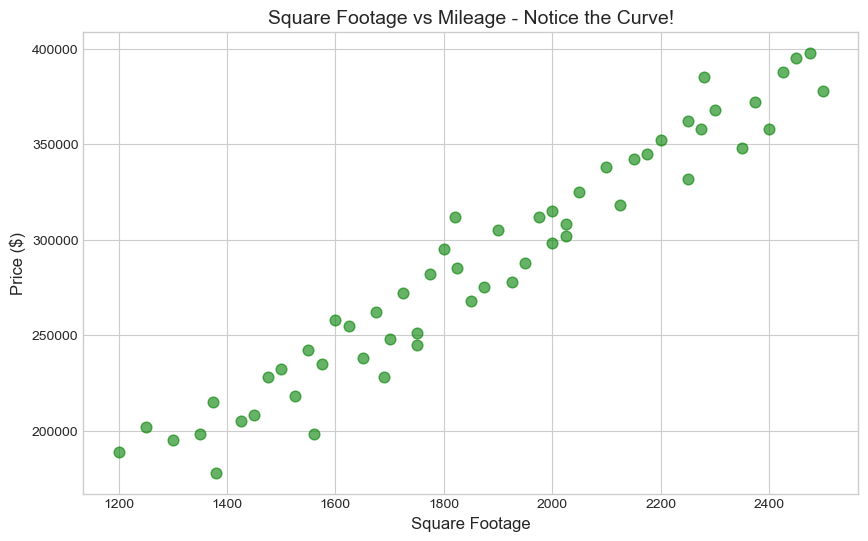

In [7]:
# Problem 1.3: Create a scatter plot

# Your code here
plt.figure(figsize=(10, 6))

# Create scatter plot - your code here
plt.scatter(housing_df['SquareFootage'], housing_df['Price'], color='green', alpha=0.6, s=60)
plt.xlabel('Square Footage', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Square Footage vs Mileage - Notice the Curve!', fontsize=14)


# Add title and labels - your code here


plt.show()

In [10]:
# Test cases for Problem 1.3 - DO NOT MODIFY
# Visual check - if the plot displayed, you're good!
print("✓ Visual check: If you see a scatter plot above, you passed!")
print("\n💡 Did you notice the relationship is CURVED, not straight?")
print("   This is why we'll need polynomial regression for this data!")

✓ Visual check: If you see a scatter plot above, you passed!

💡 Did you notice the relationship is CURVED, not straight?
   This is why we'll need polynomial regression for this data!


---

## Section 2: Multiple Linear Regression

**AI Context:** A real estate company wants to predict house prices using multiple features. This is a classic supervised learning problem where we have multiple inputs (features) predicting one output (target).

Multiple Linear Regression uses the formula: `y = b₀ + b₁x₁ + b₂x₂ + ...`

### Problem 2.1: Prepare Features and Target

Before training a model, we need to separate our features (X) from our target (y).

**What you need to do:**
1. Create `X_housing` with the features: SquareFootage and Bedrooms
2. Create `y_housing` with the target: Price

In [8]:
# Problem 2.1: Prepare features and target

# Your code here - select features (SquareFootage and Bedrooms)
X_housing = housing_df[['SquareFootage', 'Bedrooms']]  # Replace with your code

# Your code here - select target (Price)
y_housing = housing_df['Price']  # Replace with your code

print(f"Features shape: {X_housing.shape}")
print(f"Target shape: {y_housing.shape}")

Features shape: (55, 2)
Target shape: (55,)


In [9]:
# Test cases for Problem 2.1 - DO NOT MODIFY
assert X_housing is not None, "X_housing should not be None"
assert y_housing is not None, "y_housing should not be None"
assert X_housing.shape[1] == 2, "X_housing should have 2 columns (SquareFootage and Bedrooms)"
assert len(y_housing) == len(X_housing), "X and y should have same number of rows"

print("✓ All tests passed!")

✓ All tests passed!


### Problem 2.2: Train-Test Split

We need to split our data into training and test sets to properly evaluate our model.

**What you need to do:**
1. Split the data into training (80%) and test (20%) sets
2. Use `random_state=42` for reproducibility
3. Store results in: `X_train_h`, `X_test_h`, `y_train_h`, `y_test_h`

In [10]:
# Problem 2.2: Train-test split

# Your code here - use train_test_split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)  # Replace with your code

print(f"Training set size: {len(X_train_h)}")
print(f"Test set size: {len(X_test_h)}")

Training set size: 44
Test set size: 11


In [11]:
# Test cases for Problem 2.2 - DO NOT MODIFY
assert X_train_h is not None, "X_train_h should not be None"
assert len(X_train_h) > len(X_test_h), "Training set should be larger than test set"
assert len(X_train_h) + len(X_test_h) == len(X_housing), "Train + test should equal total"

print("✓ All tests passed!")

✓ All tests passed!


### Problem 2.3: Build and Train the Model

Now let's create a Multiple Linear Regression model and train it on our data.

**What you need to do:**
1. Create a `LinearRegression` model called `lr_model`
2. Fit the model on the training data

In [12]:
# Problem 2.3: Build and train the model

# Your code here - create the model
# lr_model = None  # Replace with your code
lr_model = LinearRegression()
lr_model.fit(X_train_h, y_train_h)

# Your code here - fit the model on training data


print("Model trained!")
print(f"Coefficients: {lr_model.coef_}")
print(f"Intercept: {lr_model.intercept_}")

Model trained!
Coefficients: [  176.11738342 -3239.51715746]
Intercept: -30644.003595861315


In [13]:
# Test cases for Problem 2.3 - DO NOT MODIFY
assert lr_model is not None, "lr_model should not be None"
assert hasattr(lr_model, 'coef_'), "Model should be fitted (should have coef_ attribute)"
assert len(lr_model.coef_) == 2, "Model should have 2 coefficients (one per feature)"

print("✓ All tests passed!")

✓ All tests passed!


### Problem 2.4: Evaluate and Check for Overfitting

**This is the KEY skill** - comparing training vs test performance to detect overfitting!

**What you need to do:**
1. Calculate R² score on the TRAINING set → `train_r2_lr`
2. Calculate R² score on the TEST set → `test_r2_lr`
3. Print both scores and analyze: Is this model overfitting?

In [14]:
# Problem 2.4: Evaluate and check for overfitting

# Your code here - calculate R² on training data

# What do I put here?
train_r2_lr = lr_model.score(X_train_h, y_train_h)  # Replace with your code
# test_r2_lr = lr_model.score(X_test_h, y_test_h)
   # Replace with your code (use lr_model.score() or r2_score())

# Your code here - calculate R² on test data
test_r2_lr = lr_model.score(X_test_h, y_test_h)  # Replace with your code

print(f"Training R² Score: {train_r2_lr:.4f}")
print(f"Test R² Score: {test_r2_lr:.4f}")
print(f"Gap: {train_r2_lr - test_r2_lr:.4f}")

Training R² Score: 0.9473
Test R² Score: 0.9244
Gap: 0.0229


In [15]:
# Test cases for Problem 2.4 - DO NOT MODIFY
assert train_r2_lr is not None, "train_r2_lr should not be None"
assert test_r2_lr is not None, "test_r2_lr should not be None"
assert 0 <= train_r2_lr <= 1, "R² should be between 0 and 1"
assert 0 <= test_r2_lr <= 1, "R² should be between 0 and 1"

print("✓ All tests passed!")

# Overfitting analysis
gap = train_r2_lr - test_r2_lr
if gap < 0.05:
    print("\n💚 Good fit! Small gap between training and test scores.")
elif gap < 0.15:
    print("\n🟡 Moderate gap. Some overfitting may be occurring.")
else:
    print("\n🔴 Large gap! This model is likely overfitting.")

✓ All tests passed!

💚 Good fit! Small gap between training and test scores.


---

## Section 3: Polynomial Regression

**AI Context:** A car dealership wants to predict used car trade-in values. Car depreciation isn't linear - cars lose value quickly at first, then more slowly. This is a CURVED relationship!

Polynomial Regression uses: `y = b₀ + b₁x + b₂x² + b₃x³ + ...`

### Problem 3.1: Prepare Car Data

Let's prepare the car data for modeling.

**What you need to do:**
1. Create `X_car` with Mileage (reshape to 2D array with `.values.reshape(-1, 1)`)
2. Create `y_car` with Price
3. Split into train/test (80/20) with `random_state=42`

In [ ]:
# Problem 3.1: Prepare car data

# Your code here - prepare X and y
X_car = None  # Replace - remember to reshape to 2D!
y_car = None  # Replace

# Your code here - train/test split
X_train_c, X_test_c, y_train_c, y_test_c = None, None, None, None  # Replace

print(f"Training set: {len(X_train_c)} samples")
print(f"Test set: {len(X_test_c)} samples")

In [ ]:
# Test cases for Problem 3.1 - DO NOT MODIFY
assert X_car is not None, "X_car should not be None"
assert len(X_car.shape) == 2, "X_car should be 2D (use reshape)"
assert X_train_c is not None, "X_train_c should not be None"

print("✓ All tests passed!")

### Problem 3.2: Build Linear Model First (Baseline)

Let's first try a simple linear model to see how well it fits the curved data.

**What you need to do:**
1. Create and train a `LinearRegression` model on the car data
2. Calculate training and test R² scores

In [ ]:
# Problem 3.2: Build linear model as baseline

# Your code here - create and train linear model
car_linear_model = None  # Replace

# Fit the model


# Your code here - calculate R² scores
train_r2_linear = None  # Replace
test_r2_linear = None  # Replace

print(f"Linear Model - Training R²: {train_r2_linear:.4f}")
print(f"Linear Model - Test R²: {test_r2_linear:.4f}")

In [ ]:
# Test cases for Problem 3.2 - DO NOT MODIFY
assert car_linear_model is not None, "car_linear_model should not be None"
assert train_r2_linear is not None, "train_r2_linear should not be None"

print("✓ All tests passed!")
print("\n💡 Notice the R² scores - a straight line doesn't fit curved data well!")

### Problem 3.3: Build Polynomial Model (Degree 2)

Now let's try polynomial regression to capture the curve!

**What you need to do:**
1. Create `PolynomialFeatures` with degree=2
2. Transform the training and test features
3. Train a `LinearRegression` on the polynomial features
4. Calculate training and test R² scores

In [ ]:
# Problem 3.3: Build polynomial model

# Your code here - create polynomial features transformer
poly = None  # Replace - use PolynomialFeatures(degree=2)

# Your code here - transform training and test data
X_train_poly = None  # Replace - use poly.fit_transform() on training
X_test_poly = None  # Replace - use poly.transform() on test (NOT fit_transform!)

# Your code here - create and train linear regression on polynomial features
car_poly_model = None  # Replace

# Fit the model


# Your code here - calculate R² scores
train_r2_poly = None  # Replace
test_r2_poly = None  # Replace

print(f"Polynomial Model - Training R²: {train_r2_poly:.4f}")
print(f"Polynomial Model - Test R²: {test_r2_poly:.4f}")

In [ ]:
# Test cases for Problem 3.3 - DO NOT MODIFY
assert poly is not None, "poly should not be None"
assert car_poly_model is not None, "car_poly_model should not be None"
assert train_r2_poly is not None, "train_r2_poly should not be None"
assert train_r2_poly > train_r2_linear, "Polynomial should fit better than linear for curved data!"

print("✓ All tests passed!")
print(f"\n🎉 Polynomial R² ({test_r2_poly:.4f}) is better than Linear R² ({test_r2_linear:.4f})!")

### Problem 3.4: Visualize Linear vs Polynomial Fit

Let's visualize how much better polynomial regression fits the curved data.

**What you need to do:**
1. Create a scatter plot of the actual data points
2. Plot the linear regression prediction line
3. Plot the polynomial regression prediction curve
4. Add a legend to distinguish them

In [ ]:
# Problem 3.4: Visualize linear vs polynomial fit

plt.figure(figsize=(12, 6))

# Plot actual data points
plt.scatter(X_car, y_car, alpha=0.6, label='Actual Data')

# Create smooth line for predictions
X_plot = np.linspace(X_car.min(), X_car.max(), 100).reshape(-1, 1)

# Your code here - predict with linear model and plot
# Hint: plt.plot(X_plot, predictions, label='Linear', color='red')


# Your code here - predict with polynomial model and plot
# Hint: First transform X_plot with poly.transform(), then predict


plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Car Price Prediction: Linear vs Polynomial')
plt.legend()
plt.show()

In [ ]:
# Test cases for Problem 3.4 - DO NOT MODIFY
print("✓ Visual check: If you see the scatter plot with two fitted lines, you passed!")
print("\n💡 The polynomial curve should follow the data much better than the straight line!")

---

## Section 4: Decision Tree Regression

**AI Context:** An AI system needs to predict prices using a completely different approach - instead of equations, decision trees use a series of yes/no questions to make predictions.

Decision Trees split data based on feature values to make predictions.

### Problem 4.1: Build a Decision Tree Regressor

Let's try a decision tree on the housing data.

**What you need to do:**
1. Create a `DecisionTreeRegressor` with `max_depth=3` and `random_state=42`
2. Train it on the housing training data

In [ ]:
# Problem 4.1: Build decision tree regressor

# Your code here - create the model
tree_model = None  # Replace - use DecisionTreeRegressor(max_depth=3, random_state=42)

# Your code here - fit on housing training data


print("Decision Tree trained!")
print(f"Tree depth: {tree_model.get_depth()}")

In [ ]:
# Test cases for Problem 4.1 - DO NOT MODIFY
assert tree_model is not None, "tree_model should not be None"
assert hasattr(tree_model, 'tree_'), "Model should be fitted"
assert tree_model.max_depth == 3, "max_depth should be 3"

print("✓ All tests passed!")

### Visualize Your Decision Tree! 🌳

Run the cell below to see a visual representation of the decision tree you just created. This shows how the tree splits the data at each node!

In [ ]:
# Visualize Decision Tree - Just run this cell! (provided for you)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree_model, 
          feature_names=['SquareFootage', 'Bedrooms'],
          filled=True,
          rounded=True,
          fontsize=12,
          proportion=True)
plt.title('Decision Tree Visualization: How the Model Makes Predictions', fontsize=16)
plt.tight_layout()
plt.show()

print("\n📊 How to read this tree:")
print("   • Each box shows a yes/no question about a feature")
print("   • 'samples' = percentage of data at that node")
print("   • 'value' = predicted price at that node")
print("   • Darker colors = more confident predictions")
print("   • Follow the path from top to bottom to see how predictions are made!")

### Problem 4.2: Evaluate Decision Tree Performance

Let's see how the decision tree performs and check for overfitting.

**What you need to do:**
1. Calculate training R² and MSE
2. Calculate test R² and MSE
3. Compare the scores

In [ ]:
# Problem 4.2: Evaluate decision tree

# Your code here - calculate training scores
train_r2_tree = None  # Replace
y_train_pred_tree = tree_model.predict(X_train_h)
train_mse_tree = None  # Replace - use mean_squared_error(y_train_h, y_train_pred_tree)

# Your code here - calculate test scores
test_r2_tree = None  # Replace
y_test_pred_tree = tree_model.predict(X_test_h)
test_mse_tree = None  # Replace

print(f"Decision Tree - Training R²: {train_r2_tree:.4f}, MSE: {train_mse_tree:,.0f}")
print(f"Decision Tree - Test R²: {test_r2_tree:.4f}, MSE: {test_mse_tree:,.0f}")

In [ ]:
# Test cases for Problem 4.2 - DO NOT MODIFY
assert train_r2_tree is not None, "train_r2_tree should not be None"
assert test_r2_tree is not None, "test_r2_tree should not be None"
assert train_mse_tree is not None, "train_mse_tree should not be None"

print("✓ All tests passed!")

### Problem 4.3: Compare All Models

Let's create a summary comparing Linear Regression vs Decision Tree on the housing data.

**What you need to do:**
1. Create a DataFrame comparing the models
2. Include training R², test R², and the gap between them

In [ ]:
# Problem 4.3: Compare all models

# Your code here - create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'Train R²': [None, None],  # Replace with actual values
    'Test R²': [None, None],   # Replace with actual values
    'Gap': [None, None]        # Replace with (train - test)
})

comparison_df

In [ ]:
# Test cases for Problem 4.3 - DO NOT MODIFY
assert comparison_df is not None, "comparison_df should not be None"
assert len(comparison_df) == 2, "Should have 2 rows (2 models)"
assert 'Train R²' in comparison_df.columns, "Should have 'Train R²' column"
assert 'Gap' in comparison_df.columns, "Should have 'Gap' column"

print("✓ All tests passed!")
print("\n💡 Which model has the smallest gap? That model generalizes best!")

### Problem 4.4: Visualize Predictions vs Actual

A key visualization for detecting model fit - plotting predicted vs actual values.

**What you need to do:**
1. Create a scatter plot of actual prices vs predicted prices (test set)
2. Add a diagonal line (perfect predictions would fall on this line)
3. Points close to the diagonal = good predictions!

In [ ]:
# Problem 4.4: Predictions vs Actual plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression predictions
y_pred_lr = lr_model.predict(X_test_h)

# Your code here - scatter plot for Linear Regression (left plot)
axes[0].scatter(y_test_h, y_pred_lr, alpha=0.6)
# Add diagonal line - your code here

axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Linear Regression (R² = {test_r2_lr:.3f})')

# Your code here - scatter plot for Decision Tree (right plot)
axes[1].scatter(y_test_h, y_test_pred_tree, alpha=0.6)
# Add diagonal line - your code here

axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Decision Tree (R² = {test_r2_tree:.3f})')

plt.tight_layout()
plt.show()

In [ ]:
# Test cases for Problem 4.4 - DO NOT MODIFY
print("✓ Visual check: If you see two scatter plots with diagonal lines, you passed!")
print("\n💡 Points closer to the diagonal line = better predictions!")

---

## Section 5: Detecting Overfitting Challenge

**AI Context:** The most critical skill for any data scientist - knowing when your model is fooling itself! An overfit model performs great on training data but fails on new data.

### Problem 5.1: Create an Overfit Model

Let's intentionally create an overfit model to see what overfitting looks like!

**What you need to do:**
1. Create a polynomial model with degree=10 (way too high!)
2. Train it on the car data
3. Calculate training and test R² scores

In [ ]:
# Problem 5.1: Create an overfit model

# Your code here - create high degree polynomial
poly_overfit = None  # Replace - use PolynomialFeatures(degree=10)

# Transform data
X_train_overfit = None  # Replace
X_test_overfit = None  # Replace

# Train model
overfit_model = LinearRegression()
# Your code here - fit the model


# Calculate scores
train_r2_overfit = None  # Replace
test_r2_overfit = None  # Replace

print(f"Overfit Model - Training R²: {train_r2_overfit:.4f}")
print(f"Overfit Model - Test R²: {test_r2_overfit:.4f}")
print(f"Gap: {train_r2_overfit - test_r2_overfit:.4f}")

In [ ]:
# Test cases for Problem 5.1 - DO NOT MODIFY
assert poly_overfit is not None, "poly_overfit should not be None"
assert train_r2_overfit is not None, "train_r2_overfit should not be None"

print("✓ All tests passed!")

gap = train_r2_overfit - test_r2_overfit
if gap > 0.1:
    print(f"\n🔴 OVERFITTING DETECTED! Gap of {gap:.4f} is way too large!")
    print("   The model memorized the training data but can't generalize.")

### Problem 5.2: Diagnose and Explain

Let's analyze what happened and visualize the overfitting.

**What you need to do:**
1. Visualize the overfit model's predictions (it will look wiggly!)
2. Answer the questions below about what you observe

In [ ]:
# Problem 5.2: Visualize overfitting

plt.figure(figsize=(14, 5))

# Good fit (degree 2)
plt.subplot(1, 2, 1)
plt.scatter(X_car, y_car, alpha=0.6, label='Data')
X_smooth = np.linspace(X_car.min(), X_car.max(), 100).reshape(-1, 1)
plt.plot(X_smooth, car_poly_model.predict(poly.transform(X_smooth)), 'r-', linewidth=2, label='Degree 2')
plt.title(f'Good Fit (Degree 2)\nTest R² = {test_r2_poly:.3f}')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.legend()

# Overfit (degree 10)
plt.subplot(1, 2, 2)
plt.scatter(X_car, y_car, alpha=0.6, label='Data')
# Your code here - plot the overfit model predictions
# Hint: transform X_smooth with poly_overfit, then predict with overfit_model


plt.title(f'Overfit (Degree 10)\nTest R² = {test_r2_overfit:.3f}')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Reflection - answer these questions!
print("="*60)
print("OVERFITTING ANALYSIS")
print("="*60)
print(f"\nDegree 2 Model:")
print(f"  Training R²: {train_r2_poly:.4f}")
print(f"  Test R²: {test_r2_poly:.4f}")
print(f"  Gap: {train_r2_poly - test_r2_poly:.4f}")

print(f"\nDegree 10 Model:")
print(f"  Training R²: {train_r2_overfit:.4f}")
print(f"  Test R²: {test_r2_overfit:.4f}")
print(f"  Gap: {train_r2_overfit - test_r2_overfit:.4f}")

print("\n" + "="*60)
print("KEY TAKEAWAY: Higher training score ≠ better model!")
print("Always check the GAP between training and test scores.")
print("="*60)

---

## Section 6: Lasso & Ridge Regression (Bonus)

**AI Context:** When you have many features, regularization helps prevent overfitting by penalizing large coefficients. This is a more advanced technique we touched on briefly.

- **Lasso (L1):** Can zero out features entirely
- **Ridge (L2):** Shrinks all coefficients

### Problem 6.1: Apply Lasso Regression

**What you need to do:**
1. Create a `Lasso` model with `alpha=1.0`
2. Train on housing data and calculate test R²

In [ ]:
# Problem 6.1: Lasso Regression

# Your code here
lasso_model = None  # Replace - use Lasso(alpha=1.0)

# Fit the model


# Calculate test R²
test_r2_lasso = None  # Replace

print(f"Lasso Test R²: {test_r2_lasso:.4f}")
print(f"Lasso Coefficients: {lasso_model.coef_}")

In [ ]:
# Test cases for Problem 6.1 - DO NOT MODIFY
assert lasso_model is not None, "lasso_model should not be None"
assert test_r2_lasso is not None, "test_r2_lasso should not be None"

print("✓ All tests passed!")

### Problem 6.2: Apply Ridge Regression

**What you need to do:**
1. Create a `Ridge` model with `alpha=1.0`
2. Train on housing data and calculate test R²
3. Compare all three models

In [ ]:
# Problem 6.2: Ridge Regression

# Your code here
ridge_model = None  # Replace - use Ridge(alpha=1.0)

# Fit the model


# Calculate test R²
test_r2_ridge = None  # Replace

print(f"Ridge Test R²: {test_r2_ridge:.4f}")
print(f"Ridge Coefficients: {ridge_model.coef_}")

In [ ]:
# Test cases for Problem 6.2 - DO NOT MODIFY
assert ridge_model is not None, "ridge_model should not be None"
assert test_r2_ridge is not None, "test_r2_ridge should not be None"

print("✓ All tests passed!")

# Final comparison
print("\n" + "="*50)
print("FINAL MODEL COMPARISON (Housing Data)")
print("="*50)
print(f"Linear Regression: R² = {test_r2_lr:.4f}")
print(f"Decision Tree:     R² = {test_r2_tree:.4f}")
print(f"Lasso:             R² = {test_r2_lasso:.4f}")
print(f"Ridge:             R² = {test_r2_ridge:.4f}")
print("="*50)

---

## 🎉 Congratulations!

You've completed the practice assignment! Here's what you've accomplished:

- ✅ Built **Multiple Linear Regression** models
- ✅ Built **Polynomial Regression** models to handle curved relationships
- ✅ Built **Decision Tree Regression** models
- ✅ Compared model performance using **R² and MSE**
- ✅ Created **visualizations** of predictions vs actual values
- ✅ **Detected overfitting** by comparing training vs test scores
- ✅ Explored **Lasso and Ridge** regularization

### Key Takeaways

1. **Always compare training vs test scores** - a big gap means overfitting!
2. **Different algorithms for different data** - polynomial for curves, trees for complex patterns
3. **Visualizations reveal the truth** - always plot predictions vs actual
4. **Simpler is often better** - don't over-complicate your model

### What's Next?

Keep practicing these concepts! In upcoming classes, we'll explore more advanced techniques and work on your capstone projects.

**Remember:** The Unit 2 Incremental Capstone is due **January 19, 2026**!